<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks%5C51_ITS_TSLA_SP500_inclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. ITS 실습: TSLA의 S&P 500 편입 효과
## Interrupted Time Series Analysis — Bilingual Inference Version

### 학습 목표
1. ITS의 수준 변화(level change)와 추세 변화(slope change)를 구분한다.
2. HAC(Newey–West) 표준오차를 적용한다.
3. 반사실(counterfactual) 경로를 계산한다.
4. p-value와 95% 신뢰구간을 이용해 결과를 해석한다.
5. 추론 결과를 **영어와 한글 모두 출력**한다.

### 연구 질문
**TSLA의 S&P 500 편입(2020-12-21)은 거래량과 단기 변동성에 구조적 변화를 만들었는가?**

> 본 실습은 교육용 ITS 예제입니다. 실제 연구에서는 동시 시장충격, 기업 고유 뉴스, 거시경제 변화 등을 추가 검토해야 합니다.

## 1. ITS 기본 모형

\[
Y_t=\beta_0+\beta_1 Time_t+\beta_2 Post_t+\beta_3 TimeAfter_t+\varepsilon_t
\]

- \(\beta_0\): 개입 이전 초기 수준
- \(\beta_1\): 개입 이전 추세
- \(\beta_2\): 개입 직후 수준 변화
- \(\beta_3\): 개입 이후 추세 변화

## 2. 라이브러리 준비

`yfinance`는 별도 인증키 없이 Yahoo Finance 공개 데이터를 가져오는 데 사용합니다.

In [1]:
# ============================================================
# STEP 1. Import libraries
# ============================================================

# Colab에서 최초 1회만 필요
# !pip install -q yfinance pandas numpy matplotlib statsmodels

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Libraries loaded successfully.")
print("라이브러리를 정상적으로 불러왔습니다.")

Libraries loaded successfully.
라이브러리를 정상적으로 불러왔습니다.


## 3. 분석 설정

- 종목: TSLA
- 이벤트: S&P 500 편입
- 이벤트 날짜: 2020-12-21
- 분석기간: 2020-01-01 ~ 2021-06-30

In [2]:
# ============================================================
# STEP 2. Analysis configuration
# ============================================================

ticker = "TSLA"
start = "2020-01-01"
end = "2021-06-30"
event_date = pd.to_datetime("2020-12-21")

print(f"Ticker / 종목: {ticker}")
print(f"Analysis period / 분석기간: {start} ~ {end}")
print(f"Intervention date / 개입일: {event_date.date()}")

Ticker / 종목: TSLA
Analysis period / 분석기간: 2020-01-01 ~ 2021-06-30
Intervention date / 개입일: 2020-12-21


## 4. 데이터 수집

`auto_adjust=True`를 사용하여 분할과 배당 등을 반영한 수정 가격을 사용합니다.
`yfinance` 버전에 따라 MultiIndex 컬럼이 반환될 수 있으므로 이를 자동으로 처리합니다.

In [3]:
# ============================================================
# STEP 3. Download data
# ============================================================

df = yf.download(
    ticker,
    start=start,
    end=end,
    auto_adjust=True,
    progress=False
).reset_index()

# yfinance가 MultiIndex 컬럼을 반환하는 경우
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

df["Date"] = pd.to_datetime(df["Date"])

required_cols = {"Date", "Close", "Volume"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Data shape / 데이터 크기:", df.shape)
display(df.head())

Data shape / 데이터 크기: (376, 6)


,Date,Close,High,Low,Open,Volume
0,2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
1,2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2,2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
3,2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
4,2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


## 5. 변수 생성

### 결과변수
- `log_volume`: 로그 거래량
- `ret`: 일별 수익률
- `volatility_5d`: 5일 이동 변동성

### ITS 설계변수
- `time`: 전체 시간 추세
- `post`: 이벤트 이후 여부
- `time_after`: 이벤트 이후 경과 시간

In [4]:
# ============================================================
# STEP 4. Feature engineering
# ============================================================

# 거래량 로그 변환
df["log_volume"] = np.log(df["Volume"].replace(0, np.nan))

# 일별 수익률
df["ret"] = df["Close"].pct_change()

# 최근 5거래일 변동성
df["volatility_5d"] = df["ret"].rolling(window=5).std()

# 전체 시간 추세
df["time"] = np.arange(len(df))

# 이벤트 이후 더미
df["post"] = (df["Date"] >= event_date).astype(int)

if df["post"].sum() == 0:
    raise ValueError("No post-intervention observations found.")

# 이벤트 이후 첫 관측점의 시간 위치
event_time = df.loc[df["post"] == 1, "time"].iloc[0]

# 이벤트 이후 경과 시간
df["time_after"] = np.where(
    df["post"] == 1,
    df["time"] - event_time,
    0
)

# 필요한 변수의 결측 제거
df = df.dropna(
    subset=["log_volume", "ret", "volatility_5d"]
).copy()

display(
    df[
        [
            "Date", "Close", "Volume", "log_volume",
            "ret", "volatility_5d",
            "time", "post", "time_after"
        ]
    ].head(10)
)

,Date,Close,Volume,log_volume,ret,volatility_5d,time,post,time_after
5,2020-01-09,32.089333,426606000,19.871371,-0.021945,0.027452,5,0,0
6,2020-01-10,31.876667,194392500,19.085390,-0.006627,0.029935,6,0,0
7,2020-01-13,34.990665,397764000,19.801369,0.097689,0.047586,7,0,0
8,2020-01-14,35.861332,434943000,19.890726,0.024883,0.047454,8,0,0
9,2020-01-15,34.566666,260532000,19.378236,-0.036102,0.053199,9,0,0
10,2020-01-16,34.232666,326050500,19.602563,-0.009662,0.051522,10,0,0
11,2020-01-17,34.033333,204436500,19.135768,-0.005823,0.051442,11,0,0
12,2020-01-21,36.480000,267052500,19.402956,0.071890,0.041260,12,0,0
13,2020-01-22,37.970669,470535000,19.969381,0.040863,0.043360,13,0,0
14,2020-01-23,38.146667,294765000,19.501689,0.004635,0.035035,14,0,0


## 6. 개입 전/후 기술통계

회귀분석 전에 이벤트 전후 평균과 분산의 변화를 확인합니다.
이 비교 자체가 인과효과를 의미하지는 않지만, ITS 계수를 이해하는 데 유용합니다.

In [5]:
# ============================================================
# STEP 5. Descriptive statistics
# ============================================================

summary_pre_post = (
    df.groupby("post")[["log_volume", "volatility_5d", "ret"]]
      .agg(["count", "mean", "std", "median"])
)

print("Pre/Post descriptive statistics")
print("개입 전/후 기술통계")
display(summary_pre_post)

pre_means = df.loc[df["post"] == 0, ["log_volume", "volatility_5d", "ret"]].mean()
post_means = df.loc[df["post"] == 1, ["log_volume", "volatility_5d", "ret"]].mean()

mean_comparison = pd.DataFrame({
    "Pre Mean": pre_means,
    "Post Mean": post_means,
    "Difference": post_means - pre_means
})

print("Mean comparison / 평균 비교")
display(mean_comparison)

Pre/Post descriptive statistics
개입 전/후 기술통계


log_volume                              volatility_5d                    \
          count      mean      std    median         count     mean      std   
post                                                                           
0           240 19.125432 0.500929 19.174695           240 0.049338 0.027362   
1           131 18.339348 0.348976 18.322230           131 0.034623 0.018596   

                ret                             
       median count     mean      std   median  
post                                            
0    0.046186   240 0.009823 0.057371 0.005784  
1    0.030113   131 0.000554 0.038262 0.000825

Mean comparison / 평균 비교


,Pre Mean,Post Mean,Difference
log_volume,19.125432,18.339348,-0.786084
volatility_5d,0.049338,0.034623,-0.014715
ret,0.009823,0.000554,-0.009269


## 7. 이벤트 전후 시각화

그래프 제목과 축은 폰트 깨짐 방지를 위해 영어로 출력합니다.

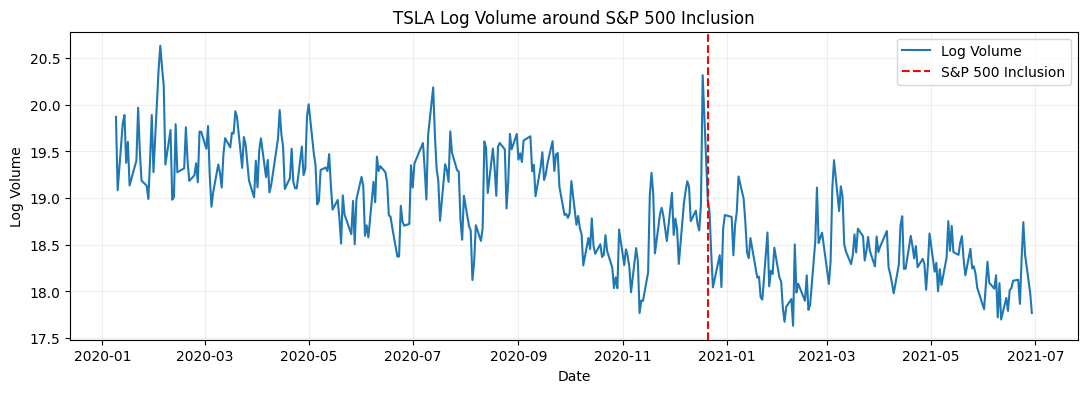

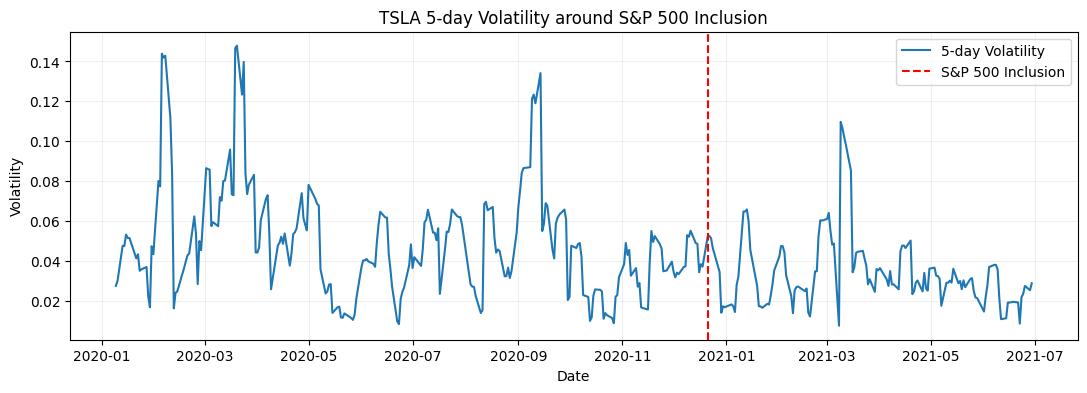

In [6]:
# ============================================================
# STEP 6. Visual inspection
# ============================================================

plt.figure(figsize=(13, 4))
plt.plot(df["Date"], df["log_volume"], label="Log Volume")
plt.axvline(event_date, color="red", linestyle="--", label="S&P 500 Inclusion")
plt.title("TSLA Log Volume around S&P 500 Inclusion")
plt.xlabel("Date")
plt.ylabel("Log Volume")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(13, 4))
plt.plot(df["Date"], df["volatility_5d"], label="5-day Volatility")
plt.axvline(event_date, color="red", linestyle="--", label="S&P 500 Inclusion")
plt.title("TSLA 5-day Volatility around S&P 500 Inclusion")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. ITS 회귀 — 로그 거래량

시계열 잔차의 자기상관 가능성을 고려하여 HAC(Newey–West) 표준오차를 사용합니다.

In [7]:
# ============================================================
# STEP 7. ITS regression for log volume
# ============================================================

model_vol = smf.ols(
    "log_volume ~ time + post + time_after",
    data=df
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

print(model_vol.summary())

                            OLS Regression Results                            
Dep. Variable:             log_volume   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     93.04
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           8.51e-45
Time:                        07:49:08   Log-Likelihood:                -177.18
No. Observations:                 371   AIC:                             362.4
Df Residuals:                     367   BIC:                             378.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.6196      0.075    259.873      0.0

## 9. ITS 회귀 — 5일 변동성

In [8]:
# ============================================================
# STEP 8. ITS regression for volatility
# ============================================================

model_sigma = smf.ols(
    "volatility_5d ~ time + post + time_after",
    data=df
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

print(model_sigma.summary())

                            OLS Regression Results                            
Dep. Variable:          volatility_5d   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     8.175
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.79e-05
Time:                        07:49:09   Log-Likelihood:                 861.83
No. Observations:                 371   AIC:                            -1716.
Df Residuals:                     367   BIC:                            -1700.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0625      0.008      8.115      0.0

## 10. 핵심 계수 표

`time`, `post`, `time_after`의 계수, 표준오차, p-value, 95% 신뢰구간만 추출합니다.

In [9]:
# ============================================================
# STEP 9. Compact coefficient tables
# ============================================================

def make_coef_table(model, variables):
    ci = model.conf_int()
    table = pd.DataFrame({
        "Coefficient": model.params,
        "Std. Error": model.bse,
        "t/z": model.tvalues,
        "p-value": model.pvalues,
        "CI Lower": ci[0],
        "CI Upper": ci[1]
    })
    return table.loc[variables]

volume_coef_table = make_coef_table(
    model_vol,
    ["time", "post", "time_after"]
)

volatility_coef_table = make_coef_table(
    model_sigma,
    ["time", "post", "time_after"]
)

print("Volume Model / 거래량 모형")
display(volume_coef_table)

print("Volatility Model / 변동성 모형")
display(volatility_coef_table)

Volume Model / 거래량 모형


,Coefficient,Std. Error,t/z,p-value,CI Lower,CI Upper
time,-0.003969,0.000666,-5.962996,0.000000,-0.005274,-0.002665
post,-0.143398,0.154512,-0.928073,0.353369,-0.446236,0.159439
time_after,0.001440,0.001427,1.009124,0.312915,-0.001357,0.004238


Volatility Model / 변동성 모형


,Coefficient,Std. Error,t/z,p-value,CI Lower,CI Upper
time,-0.000105,0.000048,-2.210779,0.027051,-0.000199,-0.000012
post,0.005580,0.008380,0.665893,0.505479,-0.010844,0.022004
time_after,-0.000011,0.000077,-0.145736,0.884130,-0.000163,0.000141


## 11. 반사실 경로 계산

개입이 없었다면 `post=0`, `time_after=0`이므로

\[
\hat{Y}^{CF}_t = \hat{\beta}_0 + \hat{\beta}_1 Time_t
\]

로 반사실 경로를 계산할 수 있습니다.

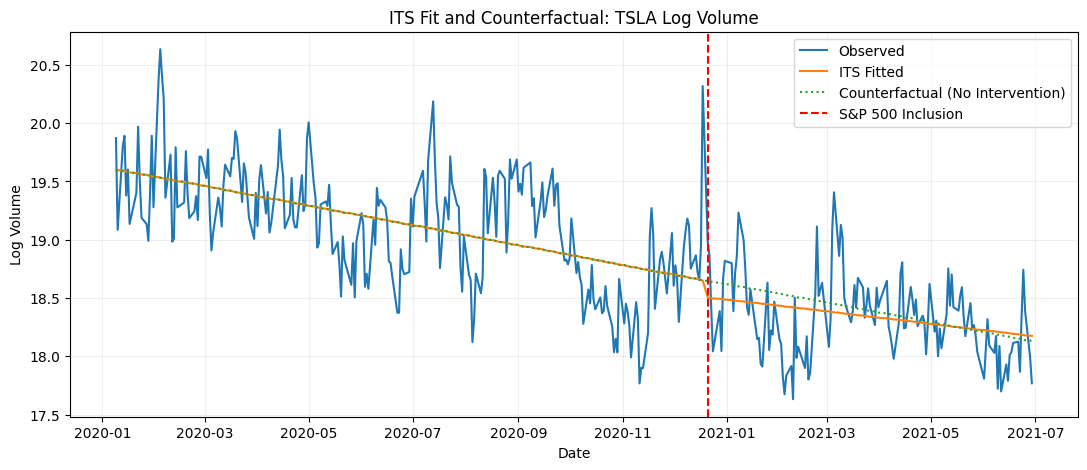

In [10]:
# ============================================================
# STEP 10. Counterfactual path
# ============================================================

# ITS 적합값
df["fitted_log_volume"] = model_vol.predict(df)

# 개입이 없었다고 가정한 반사실 경로
df["counterfactual_log_volume"] = (
    model_vol.params["Intercept"]
    + model_vol.params["time"] * df["time"]
)

# 관측값 - 반사실
df["estimated_log_effect"] = (
    df["log_volume"] - df["counterfactual_log_volume"]
)

# 로그 차이를 백분율로 변환
df["estimated_pct_effect"] = (
    np.exp(df["estimated_log_effect"]) - 1
) * 100

plt.figure(figsize=(13, 5))
plt.plot(df["Date"], df["log_volume"], label="Observed")
plt.plot(df["Date"], df["fitted_log_volume"], label="ITS Fitted")
plt.plot(
    df["Date"],
    df["counterfactual_log_volume"],
    label="Counterfactual (No Intervention)",
    linestyle=":"
)
plt.axvline(event_date, color="red", linestyle="--", label="S&P 500 Inclusion")
plt.title("ITS Fit and Counterfactual: TSLA Log Volume")
plt.xlabel("Date")
plt.ylabel("Log Volume")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 12. 이벤트 이후 평균 반사실 효과

In [11]:
# ============================================================
# STEP 11. Counterfactual effect summary
# ============================================================

post_df = df[df["post"] == 1].copy()

observed_mean_log = post_df["log_volume"].mean()
counterfactual_mean_log = post_df["counterfactual_log_volume"].mean()

mean_log_effect = observed_mean_log - counterfactual_mean_log
approx_pct_effect = (np.exp(mean_log_effect) - 1) * 100

counterfactual_summary = pd.DataFrame({
    "Metric": [
        "Observed Mean Log Volume",
        "Counterfactual Mean Log Volume",
        "Mean Log Difference",
        "Approx. Percentage Effect (%)"
    ],
    "Value": [
        observed_mean_log,
        counterfactual_mean_log,
        mean_log_effect,
        approx_pct_effect
    ]
})

display(counterfactual_summary)

print(
    f"Average estimated percentage effect / 평균 추정 백분율 효과: "
    f"{approx_pct_effect:.2f}%"
)

,Metric,Value
0,Observed Mean Log Volume,18.339348
1,Counterfactual Mean Log Volume,18.389125
2,Mean Log Difference,-0.049777
3,Approx. Percentage Effect (%),-4.855883


Average estimated percentage effect / 평균 추정 백분율 효과: -4.86%


## 13. 추정 효과의 시간 경로

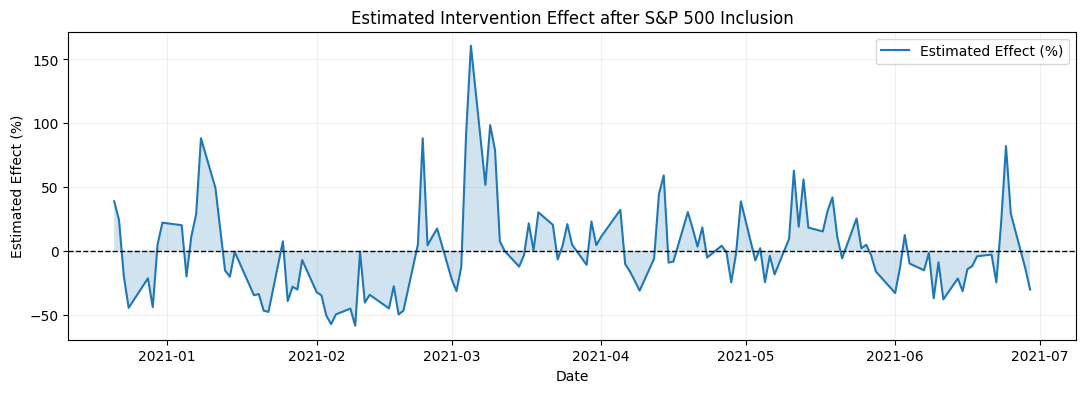

In [12]:
# ============================================================
# STEP 12. Plot intervention effect over time
# ============================================================

plt.figure(figsize=(13, 4))
plt.plot(
    post_df["Date"],
    post_df["estimated_pct_effect"],
    label="Estimated Effect (%)"
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.fill_between(
    post_df["Date"],
    0,
    post_df["estimated_pct_effect"],
    alpha=0.20
)

plt.title("Estimated Intervention Effect after S&P 500 Inclusion")
plt.xlabel("Date")
plt.ylabel("Estimated Effect (%)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 14. Ljung–Box 잔차 진단

- 귀무가설: 잔차에 자기상관이 없다.
- p-value < 0.05: 잔차 자기상관이 남아 있을 가능성
- p-value ≥ 0.05: 잔차 자기상관에 대한 강한 증거가 없음

In [13]:
# ============================================================
# STEP 13. Ljung-Box diagnostics
# ============================================================

lb_volume = acorr_ljungbox(
    model_vol.resid,
    lags=[5, 10],
    return_df=True
)

lb_volatility = acorr_ljungbox(
    model_sigma.resid,
    lags=[5, 10],
    return_df=True
)

print("Ljung-Box: Volume Model / 거래량 모형")
display(lb_volume)

print("Ljung-Box: Volatility Model / 변동성 모형")
display(lb_volatility)

Ljung-Box: Volume Model / 거래량 모형


,lb_stat,lb_pvalue
5,291.621337,0.000000
10,352.796750,0.000000


Ljung-Box: Volatility Model / 변동성 모형


,lb_stat,lb_pvalue
5,498.669717,0.000000
10,508.843757,0.000000


## 15. 영어 + 한글 ITS 자동 추론 함수

다음 함수는 수준 변화, 추세 변화, 신뢰구간, p-value를 읽고
**영어와 한글 해석을 모두 출력**합니다.

In [14]:
# ============================================================
# STEP 14. Bilingual ITS inference function
# ============================================================

def bilingual_its_inference(
    model,
    outcome_name_en,
    outcome_name_ko,
    log_outcome=False,
    alpha=0.05
):
    # 핵심 ITS 계수
    level_coef = model.params["post"]
    level_p = model.pvalues["post"]

    slope_coef = model.params["time_after"]
    slope_p = model.pvalues["time_after"]

    # 신뢰구간
    ci = model.conf_int(alpha=alpha)
    level_ci_low = ci.loc["post", 0]
    level_ci_high = ci.loc["post", 1]
    slope_ci_low = ci.loc["time_after", 0]
    slope_ci_high = ci.loc["time_after", 1]

    result_table = pd.DataFrame({
        "Effect": [
            "Immediate Level Change",
            "Post-event Slope Change"
        ],
        "Coefficient": [level_coef, slope_coef],
        "CI Lower": [level_ci_low, slope_ci_low],
        "CI Upper": [level_ci_high, slope_ci_high],
        "p-value": [level_p, slope_p],
        "Significant (5%)": [
            "Yes" if level_p < alpha else "No",
            "Yes" if slope_p < alpha else "No"
        ]
    })

    print("=" * 90)
    print("ITS INFERENCE REPORT / ITS 추론 결과")
    print(f"{outcome_name_en} / {outcome_name_ko}")
    print("=" * 90)

    display(result_table.round(6))

    # --------------------------------------------------------
    # Immediate level change
    # --------------------------------------------------------
    print("\n[1] Immediate Level Change / 즉각적 수준 변화")
    print("-" * 90)
    print(f"Coefficient / 계수: {level_coef:.6f}")
    print(f"95% CI / 95% 신뢰구간: [{level_ci_low:.6f}, {level_ci_high:.6f}]")
    print(f"p-value / 유의확률: {level_p:.6f}")

    if log_outcome:
        level_pct = (np.exp(level_coef) - 1) * 100
        print(f"Approx. % change / 대략적 변화율: {level_pct:.2f}%")

    if level_p < alpha:
        if level_coef > 0:
            en_level = (
                "There is statistically significant evidence of an immediate "
                "increase after the intervention."
            )
            ko_level = (
                "개입 직후 결과변수가 통계적으로 유의하게 증가한 것으로 나타났습니다."
            )
        else:
            en_level = (
                "There is statistically significant evidence of an immediate "
                "decrease after the intervention."
            )
            ko_level = (
                "개입 직후 결과변수가 통계적으로 유의하게 감소한 것으로 나타났습니다."
            )
    else:
        en_dir = "positive" if level_coef > 0 else "negative"
        ko_dir = "양(+)의" if level_coef > 0 else "음(-)의"

        en_level = (
            f"The immediate level change is {en_dir}, "
            "but it is not statistically significant at the 5% level."
        )
        ko_level = (
            f"개입 직후 수준 변화는 {ko_dir} 방향이지만, "
            "5% 유의수준에서 통계적으로 유의하지 않습니다."
        )

    print("\nEnglish interpretation:")
    print(en_level)
    print("\n한글 해석:")
    print(ko_level)

    # --------------------------------------------------------
    # Slope change
    # --------------------------------------------------------
    print("\n[2] Post-event Slope Change / 개입 이후 추세 변화")
    print("-" * 90)
    print(f"Coefficient / 계수: {slope_coef:.6f}")
    print(f"95% CI / 95% 신뢰구간: [{slope_ci_low:.6f}, {slope_ci_high:.6f}]")
    print(f"p-value / 유의확률: {slope_p:.6f}")

    if slope_p < alpha:
        if slope_coef > 0:
            en_slope = "The post-intervention trend increased significantly."
            ko_slope = "개입 이후 추세의 기울기가 통계적으로 유의하게 증가했습니다."
        else:
            en_slope = "The post-intervention trend decreased significantly."
            ko_slope = "개입 이후 추세의 기울기가 통계적으로 유의하게 감소했습니다."
    else:
        en_dir = "positive" if slope_coef > 0 else "negative"
        ko_dir = "양(+)의" if slope_coef > 0 else "음(-)의"

        en_slope = (
            f"The estimated slope change is {en_dir}, "
            "but it is not statistically significant at the 5% level."
        )
        ko_slope = (
            f"추정된 추세 변화는 {ko_dir} 방향이지만, "
            "5% 유의수준에서 통계적으로 유의하지 않습니다."
        )

    print("\nEnglish interpretation:")
    print(en_slope)
    print("\n한글 해석:")
    print(ko_slope)

    # --------------------------------------------------------
    # Overall interpretation
    # --------------------------------------------------------
    print("\n[3] Overall Interpretation / 종합 해석")
    print("-" * 90)

    if level_p < alpha and slope_p < alpha:
        overall_en = (
            "The ITS model indicates both a significant immediate level change "
            "and a significant post-intervention trend change."
        )
        overall_ko = (
            "ITS 모형에서는 개입 직후 수준 변화와 개입 이후 추세 변화가 "
            "모두 통계적으로 유의하게 나타났습니다."
        )
    elif level_p < alpha and slope_p >= alpha:
        overall_en = (
            "The ITS model indicates a significant immediate effect, "
            "but limited evidence of a persistent trend change."
        )
        overall_ko = (
            "개입 직후 즉각적 효과는 통계적으로 유의하지만, "
            "지속적인 추세 변화의 증거는 제한적입니다."
        )
    elif level_p >= alpha and slope_p < alpha:
        overall_en = (
            "There is limited evidence of an immediate level effect, "
            "but the post-intervention trend changed significantly."
        )
        overall_ko = (
            "개입 직후 수준 변화의 증거는 제한적이지만, "
            "개입 이후 추세 변화는 통계적으로 유의합니다."
        )
    else:
        overall_en = (
            "The ITS model provides limited statistical evidence of either "
            "an immediate level effect or a persistent trend effect."
        )
        overall_ko = (
            "ITS 모형에서는 즉각적 수준 변화와 지속적인 추세 변화 모두에 대해 "
            "강한 통계적 증거가 제한적입니다."
        )

    print("English interpretation:")
    print(overall_en)
    print("\n한글 해석:")
    print(overall_ko)
    print("=" * 90)

    return result_table

## 16. 로그 거래량 추론 결과

In [15]:
# ============================================================
# STEP 15. Bilingual inference: log volume
# ============================================================

volume_inference_table = bilingual_its_inference(
    model=model_vol,
    outcome_name_en="TSLA Log Volume",
    outcome_name_ko="TSLA 로그 거래량",
    log_outcome=True
)

ITS INFERENCE REPORT / ITS 추론 결과
TSLA Log Volume / TSLA 로그 거래량


,Effect,Coefficient,CI Lower,CI Upper,p-value,Significant (5%)
0,Immediate Level Change,-0.143398,-0.446236,0.159439,0.353369,No
1,Post-event Slope Change,0.001440,-0.001357,0.004238,0.312915,No



[1] Immediate Level Change / 즉각적 수준 변화
------------------------------------------------------------------------------------------
Coefficient / 계수: -0.143398
95% CI / 95% 신뢰구간: [-0.446236, 0.159439]
p-value / 유의확률: 0.353369
Approx. % change / 대략적 변화율: -13.36%

English interpretation:
The immediate level change is negative, but it is not statistically significant at the 5% level.

한글 해석:
개입 직후 수준 변화는 음(-)의 방향이지만, 5% 유의수준에서 통계적으로 유의하지 않습니다.

[2] Post-event Slope Change / 개입 이후 추세 변화
------------------------------------------------------------------------------------------
Coefficient / 계수: 0.001440
95% CI / 95% 신뢰구간: [-0.001357, 0.004238]
p-value / 유의확률: 0.312915

English interpretation:
The estimated slope change is positive, but it is not statistically significant at the 5% level.

한글 해석:
추정된 추세 변화는 양(+)의 방향이지만, 5% 유의수준에서 통계적으로 유의하지 않습니다.

[3] Overall Interpretation / 종합 해석
------------------------------------------------------------------------------------------
English interpretatio

## 17. 5일 변동성 추론 결과

In [16]:
# ============================================================
# STEP 16. Bilingual inference: volatility
# ============================================================

volatility_inference_table = bilingual_its_inference(
    model=model_sigma,
    outcome_name_en="TSLA 5-day Volatility",
    outcome_name_ko="TSLA 5일 변동성",
    log_outcome=False
)

ITS INFERENCE REPORT / ITS 추론 결과
TSLA 5-day Volatility / TSLA 5일 변동성


,Effect,Coefficient,CI Lower,CI Upper,p-value,Significant (5%)
0,Immediate Level Change,0.005580,-0.010844,0.022004,0.505479,No
1,Post-event Slope Change,-0.000011,-0.000163,0.000141,0.884130,No



[1] Immediate Level Change / 즉각적 수준 변화
------------------------------------------------------------------------------------------
Coefficient / 계수: 0.005580
95% CI / 95% 신뢰구간: [-0.010844, 0.022004]
p-value / 유의확률: 0.505479

English interpretation:
The immediate level change is positive, but it is not statistically significant at the 5% level.

한글 해석:
개입 직후 수준 변화는 양(+)의 방향이지만, 5% 유의수준에서 통계적으로 유의하지 않습니다.

[2] Post-event Slope Change / 개입 이후 추세 변화
------------------------------------------------------------------------------------------
Coefficient / 계수: -0.000011
95% CI / 95% 신뢰구간: [-0.000163, 0.000141]
p-value / 유의확률: 0.884130

English interpretation:
The estimated slope change is negative, but it is not statistically significant at the 5% level.

한글 해석:
추정된 추세 변화는 음(-)의 방향이지만, 5% 유의수준에서 통계적으로 유의하지 않습니다.

[3] Overall Interpretation / 종합 해석
------------------------------------------------------------------------------------------
English interpretation:
The ITS model provides limited st

## 18. 반사실 효과 — 영어 + 한글 해석

In [17]:
# ============================================================
# STEP 17. Bilingual counterfactual interpretation
# ============================================================

print("=" * 90)
print("COUNTERFACTUAL EFFECT SUMMARY / 반사실 효과 요약")
print("=" * 90)

print(f"Observed mean log volume / 실제 평균 로그 거래량: {observed_mean_log:.6f}")
print(f"Counterfactual mean / 반사실 평균 로그 거래량: {counterfactual_mean_log:.6f}")
print(f"Mean log difference / 평균 로그 차이: {mean_log_effect:.6f}")
print(f"Approx. percentage effect / 대략적 백분율 효과: {approx_pct_effect:.2f}%")

if approx_pct_effect > 0:
    print("\nEnglish interpretation:")
    print(
        f"After the intervention, observed trading volume was on average "
        f"approximately {approx_pct_effect:.2f}% higher than the counterfactual path."
    )
    print("\n한글 해석:")
    print(
        f"개입 이후 실제 거래량은 개입이 없었다고 가정한 반사실 경로보다 "
        f"평균적으로 약 {approx_pct_effect:.2f}% 높게 나타났습니다."
    )
else:
    abs_effect = abs(approx_pct_effect)

    print("\nEnglish interpretation:")
    print(
        f"After the intervention, observed trading volume was on average "
        f"approximately {abs_effect:.2f}% lower than the counterfactual path."
    )
    print("\n한글 해석:")
    print(
        f"개입 이후 실제 거래량은 개입이 없었다고 가정한 반사실 경로보다 "
        f"평균적으로 약 {abs_effect:.2f}% 낮게 나타났습니다."
    )

print("=" * 90)

COUNTERFACTUAL EFFECT SUMMARY / 반사실 효과 요약
Observed mean log volume / 실제 평균 로그 거래량: 18.339348
Counterfactual mean / 반사실 평균 로그 거래량: 18.389125
Mean log difference / 평균 로그 차이: -0.049777
Approx. percentage effect / 대략적 백분율 효과: -4.86%

English interpretation:
After the intervention, observed trading volume was on average approximately 4.86% lower than the counterfactual path.

한글 해석:
개입 이후 실제 거래량은 개입이 없었다고 가정한 반사실 경로보다 평균적으로 약 4.86% 낮게 나타났습니다.


## 19. Ljung–Box — 영어 + 한글 자동 해석

In [18]:
# ============================================================
# STEP 18. Bilingual Ljung-Box interpretation
# ============================================================

def bilingual_ljungbox_interpretation(
    lb_result,
    model_name_en,
    model_name_ko,
    alpha=0.05
):
    print("=" * 90)
    print("LJUNG-BOX DIAGNOSTIC / LJUNG-BOX 잔차 진단")
    print(f"{model_name_en} / {model_name_ko}")
    print("=" * 90)

    display(lb_result)

    for lag, row in lb_result.iterrows():
        p_value = row["lb_pvalue"]

        print(f"\nLag {lag} / 시차 {lag}")
        print(f"p-value / 유의확률: {p_value:.6f}")

        if p_value < alpha:
            print(
                "English: Significant residual autocorrelation remains. "
                "The model may not fully capture the time-series structure."
            )
            print(
                "한글: 잔차에 유의한 자기상관이 남아 있습니다. "
                "모형이 시계열 구조를 충분히 설명하지 못했을 가능성이 있습니다."
            )
        else:
            print(
                "English: No statistically significant residual autocorrelation "
                "is detected at this lag."
            )
            print(
                "한글: 해당 시차에서는 통계적으로 유의한 잔차 자기상관이 "
                "확인되지 않았습니다."
            )

    print("=" * 90)


bilingual_ljungbox_interpretation(
    lb_volume,
    "Volume Model",
    "거래량 모형"
)

bilingual_ljungbox_interpretation(
    lb_volatility,
    "Volatility Model",
    "변동성 모형"
)

LJUNG-BOX DIAGNOSTIC / LJUNG-BOX 잔차 진단
Volume Model / 거래량 모형


,lb_stat,lb_pvalue
5,291.621337,0.000000
10,352.796750,0.000000



Lag 5 / 시차 5
p-value / 유의확률: 0.000000
English: Significant residual autocorrelation remains. The model may not fully capture the time-series structure.
한글: 잔차에 유의한 자기상관이 남아 있습니다. 모형이 시계열 구조를 충분히 설명하지 못했을 가능성이 있습니다.

Lag 10 / 시차 10
p-value / 유의확률: 0.000000
English: Significant residual autocorrelation remains. The model may not fully capture the time-series structure.
한글: 잔차에 유의한 자기상관이 남아 있습니다. 모형이 시계열 구조를 충분히 설명하지 못했을 가능성이 있습니다.
LJUNG-BOX DIAGNOSTIC / LJUNG-BOX 잔차 진단
Volatility Model / 변동성 모형


,lb_stat,lb_pvalue
5,498.669717,0.000000
10,508.843757,0.000000



Lag 5 / 시차 5
p-value / 유의확률: 0.000000
English: Significant residual autocorrelation remains. The model may not fully capture the time-series structure.
한글: 잔차에 유의한 자기상관이 남아 있습니다. 모형이 시계열 구조를 충분히 설명하지 못했을 가능성이 있습니다.

Lag 10 / 시차 10
p-value / 유의확률: 0.000000
English: Significant residual autocorrelation remains. The model may not fully capture the time-series structure.
한글: 잔차에 유의한 자기상관이 남아 있습니다. 모형이 시계열 구조를 충분히 설명하지 못했을 가능성이 있습니다.


## 20. 최종 ITS 추론 요약

강의 마지막 또는 보고서용으로 핵심 결과를 한 화면에 출력합니다.

In [19]:
# ============================================================
# STEP 19. Final bilingual ITS summary
# ============================================================

level_coef = model_vol.params["post"]
level_p = model_vol.pvalues["post"]

slope_coef = model_vol.params["time_after"]
slope_p = model_vol.pvalues["time_after"]

level_pct = (np.exp(level_coef) - 1) * 100

print("=" * 95)
print("FINAL ITS INFERENCE: TSLA S&P 500 INCLUSION")
print("최종 ITS 추론: TSLA S&P 500 편입")
print("=" * 95)

print("Event / 이벤트")
print("---------------")
print("S&P 500 Inclusion / S&P 500 편입")
print(f"Date / 날짜: {event_date.date()}")

print("\nImmediate Level Effect / 즉각적 수준 효과")
print("------------------------------------------")
print(f"Coefficient / 계수: {level_coef:.6f}")
print(f"Approx. Change / 변화율: {level_pct:.2f}%")
print(f"p-value / 유의확률: {level_p:.6f}")

print("\nPost-event Trend Effect / 개입 이후 추세 효과")
print("----------------------------------------------")
print(f"Slope Change / 기울기 변화: {slope_coef:.6f}")
print(f"p-value / 유의확률: {slope_p:.6f}")

print("\nCounterfactual Effect / 반사실 효과")
print("------------------------------------")
print(f"Average Effect / 평균 효과: {approx_pct_effect:.2f}%")

print("\nStatistical Conclusion / 통계적 결론")
print("------------------------------------")

if level_p < 0.05:
    if level_coef > 0:
        print("EN: There is significant evidence of an immediate increase after the intervention.")
        print("KO: 개입 직후 통계적으로 유의한 증가 효과가 확인되었습니다.")
    else:
        print("EN: There is significant evidence of an immediate decrease after the intervention.")
        print("KO: 개입 직후 통계적으로 유의한 감소 효과가 확인되었습니다.")
else:
    print("EN: There is no strong statistical evidence of an immediate level effect.")
    print("KO: 개입 직후 수준 효과에 대한 강한 통계적 증거는 확인되지 않았습니다.")

if slope_p < 0.05:
    if slope_coef > 0:
        print("EN: The post-intervention trend increased significantly.")
        print("KO: 개입 이후 추세가 통계적으로 유의하게 증가했습니다.")
    else:
        print("EN: The post-intervention trend decreased significantly.")
        print("KO: 개입 이후 추세가 통계적으로 유의하게 감소했습니다.")
else:
    print("EN: There is no strong evidence of a persistent post-intervention trend change.")
    print("KO: 개입 이후 지속적인 추세 변화에 대한 강한 증거는 확인되지 않았습니다.")

print("\nCausal Interpretation Note / 인과해석 주의")
print("--------------------------------------------")

print(
    "EN: This estimate is based on an Interrupted Time Series design. "
    "It does not by itself rule out contemporaneous market-wide shocks, "
    "firm-specific news, or other confounding events."
)

print(
    "KO: 본 추정치는 Interrupted Time Series 설계에 기반한 결과입니다. "
    "따라서 같은 시기의 시장 전체 충격, 기업 고유 뉴스, "
    "기타 동시적 교란 사건의 영향을 완전히 배제한 것은 아닙니다."
)

print("=" * 95)

FINAL ITS INFERENCE: TSLA S&P 500 INCLUSION
최종 ITS 추론: TSLA S&P 500 편입
Event / 이벤트
---------------
S&P 500 Inclusion / S&P 500 편입
Date / 날짜: 2020-12-21

Immediate Level Effect / 즉각적 수준 효과
------------------------------------------
Coefficient / 계수: -0.143398
Approx. Change / 변화율: -13.36%
p-value / 유의확률: 0.353369

Post-event Trend Effect / 개입 이후 추세 효과
----------------------------------------------
Slope Change / 기울기 변화: 0.001440
p-value / 유의확률: 0.312915

Counterfactual Effect / 반사실 효과
------------------------------------
Average Effect / 평균 효과: -4.86%

Statistical Conclusion / 통계적 결론
------------------------------------
EN: There is no strong statistical evidence of an immediate level effect.
KO: 개입 직후 수준 효과에 대한 강한 통계적 증거는 확인되지 않았습니다.
EN: There is no strong evidence of a persistent post-intervention trend change.
KO: 개입 이후 지속적인 추세 변화에 대한 강한 증거는 확인되지 않았습니다.

Causal Interpretation Note / 인과해석 주의
--------------------------------------------
EN: This estimate is based on an Interrupted Time

## 21. 수업 중 설명 순서

1. **그래프**: 이벤트 전후 패턴이 달라 보이는가?
2. **`post`**: 이벤트 직후 즉각적인 수준 변화가 있었는가?
3. **`time_after`**: 이벤트 이후 추세가 달라졌는가?
4. **p-value와 95% CI**: 변화에 대한 통계적 증거는 충분한가?
5. **반사실 경로**: 이벤트가 없었다면 예상되는 경로와 실제 경로가 얼마나 다른가?
6. **Ljung–Box**: 잔차에 시간 구조가 남아 있는가?
7. **한계**: 동시 시장충격이나 기업 고유 사건을 완전히 제거했는가?

## 22. 학생 토론 질문

1. S&P 500 편입은 TSLA 거래량에 즉각적인 영향을 주었는가?
2. 그 영향은 일시적이었는가, 지속적이었는가?
3. 거래량과 변동성의 결과가 다르다면 어떻게 설명할 수 있는가?
4. 같은 시기에 존재했던 잠재적 교란 사건은 무엇인가?
5. 이 연구를 DiD 또는 Synthetic Control로 확장한다면 무엇이 달라지는가?

## 23. 핵심 정리

- ITS는 **단일 시계열의 개입 전후 구조 변화**를 분석합니다.
- `post`는 **즉각적 수준 변화**, `time_after`는 **지속적 추세 변화**를 의미합니다.
- HAC 표준오차는 시계열 자기상관으로 인한 표준오차 왜곡을 완화하는 데 도움을 줍니다.
- 반사실 경로는 “개입이 없었다면?”이라는 인과추론의 핵심 질문을 시각화합니다.
- 결과는 통계적 유의성뿐 아니라 **효과크기, 신뢰구간, 잔차 진단, 동시충격 가능성**을 함께 고려해야 합니다.